In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

from scipy.signal import find_peaks, welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
def extract_bp_from_abp(abp_window):

    # Detect systolic peaks
    peaks, _ = find_peaks(
        abp_window,
        distance=50,       # ~0.4 sec at 125 Hz
        prominence=5
    )


    # Need enough beats in the window
    if len(peaks) < 2:
        return None, None


    # SBP = pressure at systolic peaks
    sbp_values = abp_window[peaks]


    dbp_values = []


    # Find minimum pressure between consecutive systolic peaks
    for i in range(len(peaks)-1):

        beat_segment = abp_window[
            peaks[i]:peaks[i+1]
        ]

        if len(beat_segment) > 0:

            dbp_values.append(
                np.min(beat_segment)
            )


    if len(dbp_values) == 0:
        return None, None


    # Use median to reduce effect of noisy beats
    sbp = np.median(sbp_values)
    dbp = np.median(dbp_values)


    # Optional sanity check
    if sbp < 50 or sbp > 250:
        return None, None

    if dbp < 20 or dbp > 150:
        return None, None


    return sbp, dbp

def process_recording(recording, WINDOW_SIZE, STEP_SIZE ):

    data = recording[:]

    ppg = data[:,0]
    abp = data[:,1]

    X = []
    y = []

    for start in range(
        0,
        len(ppg)-WINDOW_SIZE+1,
        STEP_SIZE
    ):

        ppg_window = ppg[start:start+WINDOW_SIZE]

        abp_window = abp[start:start+WINDOW_SIZE]

        sbp, dbp = extract_bp_from_abp(abp_window)

        if sbp is None:
            continue

        X.append(ppg_window)
        y.append([sbp,dbp])

    if len(X)==0:
        return None,None

    return np.array(X),np.array(y)




def process_split(record_list, WINDOW_SIZE, STEP_SIZE):

    X_all = []
    y_all = []

    skipped = 0

    for f, ref in tqdm(record_list):

        recording = f[ref]

        X, y = process_recording(recording, WINDOW_SIZE, STEP_SIZE)

        if X is None:
            skipped += 1
            continue

        X_all.append(X)
        y_all.append(y)

    X_all = np.concatenate(X_all)

    y_all = np.concatenate(y_all)

    print("Skipped recordings:", skipped)

    return X_all, y_all



def load_UCI_dataset(
    WINDOW_SIZE, 
    STEP_SIZE,
    data_path="/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/data",
    test_size=0.1,
    val_size=1/9,
    random_state=42,
    
):


    # ============================
    # Load recordings
    # ============================

    recordings = []


    for part in range(1,5):

        file_path = f"{data_path}/Part_{part}.mat"

        f = h5py.File(file_path, "r")

        dataset = f[f"Part_{part}"]


        for i in range(dataset.shape[0]):

            recordings.append(
                (f, dataset[i,0])
            )


    print("Total recordings:", len(recordings))


    # ============================
    # Train-test split
    # ============================

    train_records, test_records = train_test_split(
        recordings,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )


    # ============================
    # Train-validation split
    # ============================

    train_records, val_records = train_test_split(
        train_records,
        test_size=val_size,
        random_state=random_state,
        shuffle=True
    )


    print(
        f"Train recordings: {len(train_records)}"
    )

    print(
        f"Validation recordings: {len(val_records)}"
    )

    print(
        f"Test recordings: {len(test_records)}"
    )


    # ============================
    # Preprocessing
    # ============================

    X_train, y_train = process_split(train_records,WINDOW_SIZE, 
    STEP_SIZE)

    X_val, y_val = process_split(val_records,WINDOW_SIZE, 
    STEP_SIZE)

    X_test, y_test = process_split(test_records,WINDOW_SIZE, 
    STEP_SIZE)

    # ===========================
    # Add channel dimension
    # CNN input:
    # (batch, channels, samples)
    # ============================

    X_train = X_train[:,None,:]

    X_val = X_val[:,None,:]

    X_test = X_test[:,None,:]

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(WINDOW_SIZE= 625, STEP_SIZE= 625)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:21<00:00, 118.38it/s]


Skipped recordings: 6


100%|██████████| 1200/1200 [00:10<00:00, 114.57it/s]


Skipped recordings: 1


100%|██████████| 1200/1200 [00:10<00:00, 114.52it/s]


Skipped recordings: 0


In [ ]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (421829, 1, 625), y_train shape: (421829, 2)


## Feature Exraction - Non-fiducial features ##

We'll extract 19 features

In [4]:
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import savgol_filter

In [ ]:
def extract_nonfiducial_features(signal):

    signal = np.asarray(signal, dtype=np.float64)

    signal = signal[np.isfinite(signal)]

    if len(signal) == 0:
        return {}

    # -----------------------------
    # Basic statistical features
    # -----------------------------

    mean_val = np.mean(signal)
    median_val = np.median(signal)
    std_val = np.std(signal)
    variance_val = np.var(signal)

    iqr_val = (
        np.percentile(signal, 75)
        - np.percentile(signal, 25)
    )

    skewness_val = skew(signal)
    kurtosis_val = kurtosis(signal)

    # -----------------------------
    # Zero crossing rate
    # -----------------------------

    zero_crossings = np.sum(
        signal[:-1] * signal[1:] < 0
    )

    zero_crossing_rate = (
        zero_crossings / (len(signal) - 1)
    )

    # -----------------------------
    # Shannon entropy
    # -----------------------------

    hist, _ = np.histogram(
        signal,
        bins=50
    )

    probabilities = hist / np.sum(hist)

    probabilities = probabilities[
        probabilities > 0
    ]

    shannon_entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    # -----------------------------
    # Energy
    # -----------------------------

    energy = signal ** 2

    energy_mean = np.mean(energy)
    energy_variance = np.var(energy)
    energy_skewness = skew(energy)
    energy_kurtosis = kurtosis(energy)

    energy_iqr = (
        np.percentile(energy, 75)
        - np.percentile(energy, 25)
    )

    # -----------------------------
    # Kaiser-Teager Energy
    # -----------------------------

    if len(signal) >= 3:

        kte = (
            signal[1:-1] ** 2
            - signal[:-2] * signal[2:]
        )

        kte_mean = np.mean(kte)
        kte_variance = np.var(kte)
        kte_skewness = skew(kte)
        kte_kurtosis = kurtosis(kte)

        kte_iqr = (
            np.percentile(kte, 75)
            - np.percentile(kte, 25)
        )

    else:

        kte_mean = np.nan
        kte_variance = np.nan
        kte_skewness = np.nan
        kte_kurtosis = np.nan
        kte_iqr = np.nan

    return {

        "mean": mean_val,
        "median": median_val,
        "std": std_val,
        "variance": variance_val,
        "iqr": iqr_val,
        "skewness": skewness_val,
        "kurtosis": kurtosis_val,

        "zero_crossing_rate": zero_crossing_rate,
        "shannon_entropy": shannon_entropy,

        "energy_mean": energy_mean,
        "energy_variance": energy_variance,
        "energy_skewness": energy_skewness,
        "energy_kurtosis": energy_kurtosis,
        "energy_iqr": energy_iqr,

        "kte_mean": kte_mean,
        "kte_variance": kte_variance,
        "kte_skewness": kte_skewness,
        "kte_kurtosis": kte_kurtosis,
        "kte_iqr": kte_iqr
    }

In [ ]:
def extract_all_features(ppg, fs=125):

    ppg = np.asarray(ppg, dtype=np.float64)

    # =========================================
    # 1. Original PPG
    # =========================================

    ppg_features = extract_nonfiducial_features(ppg)

    # =========================================
    # 2. VPG - First derivative
    # =========================================

    vpg = np.gradient(ppg)

    # Smooth VPG
    vpg = savgol_filter(
        vpg,
        window_length=11,
        polyorder=3
    )

    # =========================================
    # 3. APG - Second derivative
    # =========================================

    apg = np.gradient(vpg)

    # Smooth APG
    apg = savgol_filter(
        apg,
        window_length=11,
        polyorder=3
    )

    # =========================================
    # 4. Extract features
    # =========================================

    vpg_features = extract_nonfiducial_features(vpg)

    apg_features = extract_nonfiducial_features(apg)

    # =========================================
    # 5. Combine all 57 features
    # =========================================

    features = {}

    for name, value in ppg_features.items():
        features["ppg_" + name] = value

    for name, value in vpg_features.items():
        features["vpg_" + name] = value

    for name, value in apg_features.items():
        features["apg_" + name] = value

    return features

In [7]:
test_window = X_train[0, 0, :]

features = extract_all_features(
    test_window,
    fs=125
)

print("Number of features:", len(features))

print(features)

Number of features: 57
{'ppg_mean': np.float64(2.154428934506354), 'ppg_median': np.float64(2.220918866080156), 'ppg_std': np.float64(0.5626222659163733), 'ppg_variance': np.float64(0.3165438141048743), 'ppg_iqr': np.float64(0.9921798631476049), 'ppg_skewness': np.float64(-0.27439930015112696), 'ppg_kurtosis': np.float64(-1.1298680721917524), 'ppg_zero_crossing_rate': np.float64(0.0), 'ppg_shannon_entropy': np.float64(5.493174555139509), 'ppg_energy_mean': np.float64(4.958107847943057), 'ppg_energy_variance': np.float64(5.543081302809521), 'ppg_energy_skewness': np.float64(0.03289597109053284), 'ppg_energy_kurtosis': np.float64(-1.3027001495614008), 'ppg_energy_iqr': np.float64(4.299446073639621), 'ppg_kte_mean': np.float64(0.00581370288614723), 'ppg_kte_variance': np.float64(0.00022242662925081073), 'ppg_kte_skewness': np.float64(0.12070837247417962), 'ppg_kte_kurtosis': np.float64(1.1143132201809731), 'ppg_kte_iqr': np.float64(0.014294396046358182), 'vpg_mean': np.float64(-0.00079843

In [9]:
def extract_features_from_dataset(
    X,
    y,
    fs=125
):

    rows = []

    for i in tqdm(range(len(X))):

        ppg = X[i, 0, :]

        features = extract_all_features(
            ppg,
            fs
        )

        features["SBP"] = y[i, 0]
        features["DBP"] = y[i, 1]

        rows.append(features)

    return pd.DataFrame(rows)

In [10]:
df_train = extract_features_from_dataset(
    X_train,
    y_train
)

df_val = extract_features_from_dataset(
    X_val,
    y_val
)

df_test = extract_features_from_dataset(
    X_test,
    y_test
)

  0%|          | 389/421829 [00:03<1:03:13, 111.09it/s]


KeyboardInterrupt: 

In [ ]:
print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Train: (377898, 24)
Validation: (42700, 24)
Test: (107967, 24)


In [ ]:
print(df_train.columns.tolist())

['mean', 'std', 'skewness', 'kurtosis', 'rms', 'max', 'min', 'range', 'heart_rate', 'mean_peak_amplitude', 'std_peak_amplitude', 'mean_peak_distance', 'max_vpg', 'min_vpg', 'mean_vpg', 'std_vpg', 'max_apg', 'min_apg', 'mean_apg', 'std_apg', 'dominant_frequency', 'spectral_energy', 'SBP', 'DBP']


In [ ]:
print(df_train.isna().sum())
print(df_val.isna().sum())
print(df_test.isna().sum())

mean                   0
std                    0
skewness               0
kurtosis               0
rms                    0
max                    0
min                    0
range                  0
heart_rate             0
mean_peak_amplitude    0
std_peak_amplitude     0
mean_peak_distance     0
max_vpg                0
min_vpg                0
mean_vpg               0
std_vpg                0
max_apg                0
min_apg                0
mean_apg               0
std_apg                0
dominant_frequency     0
spectral_energy        0
SBP                    0
DBP                    0
dtype: int64
mean                   0
std                    0
skewness               0
kurtosis               0
rms                    0
max                    0
min                    0
range                  0
heart_rate             0
mean_peak_amplitude    0
std_peak_amplitude     0
mean_peak_distance     0
max_vpg                0
min_vpg                0
mean_vpg               0
std_vpg     

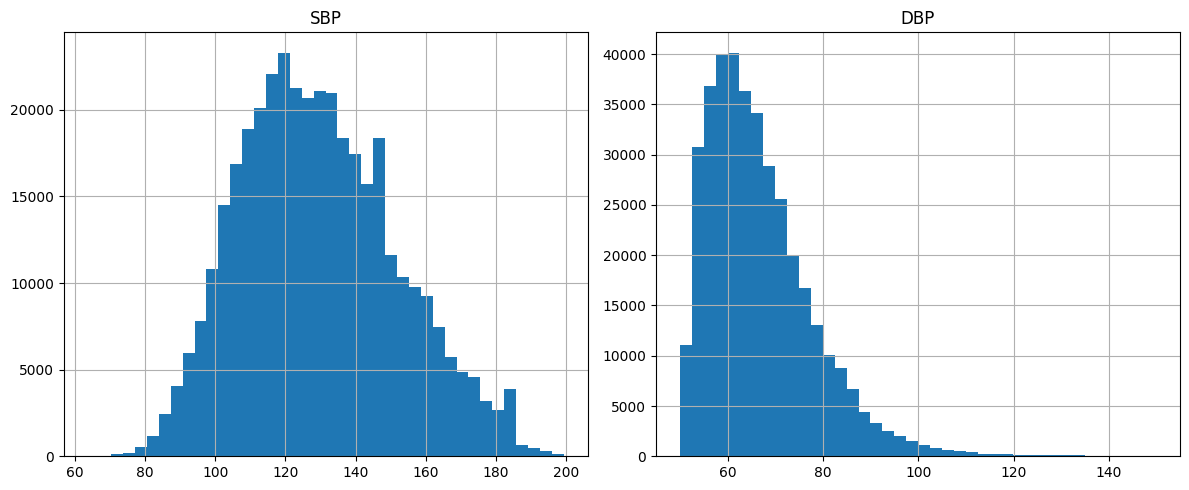

In [ ]:
df_train[["SBP", "DBP"]].hist(
    bins=40,
    figsize=(12, 5)
)

plt.tight_layout()
plt.show()

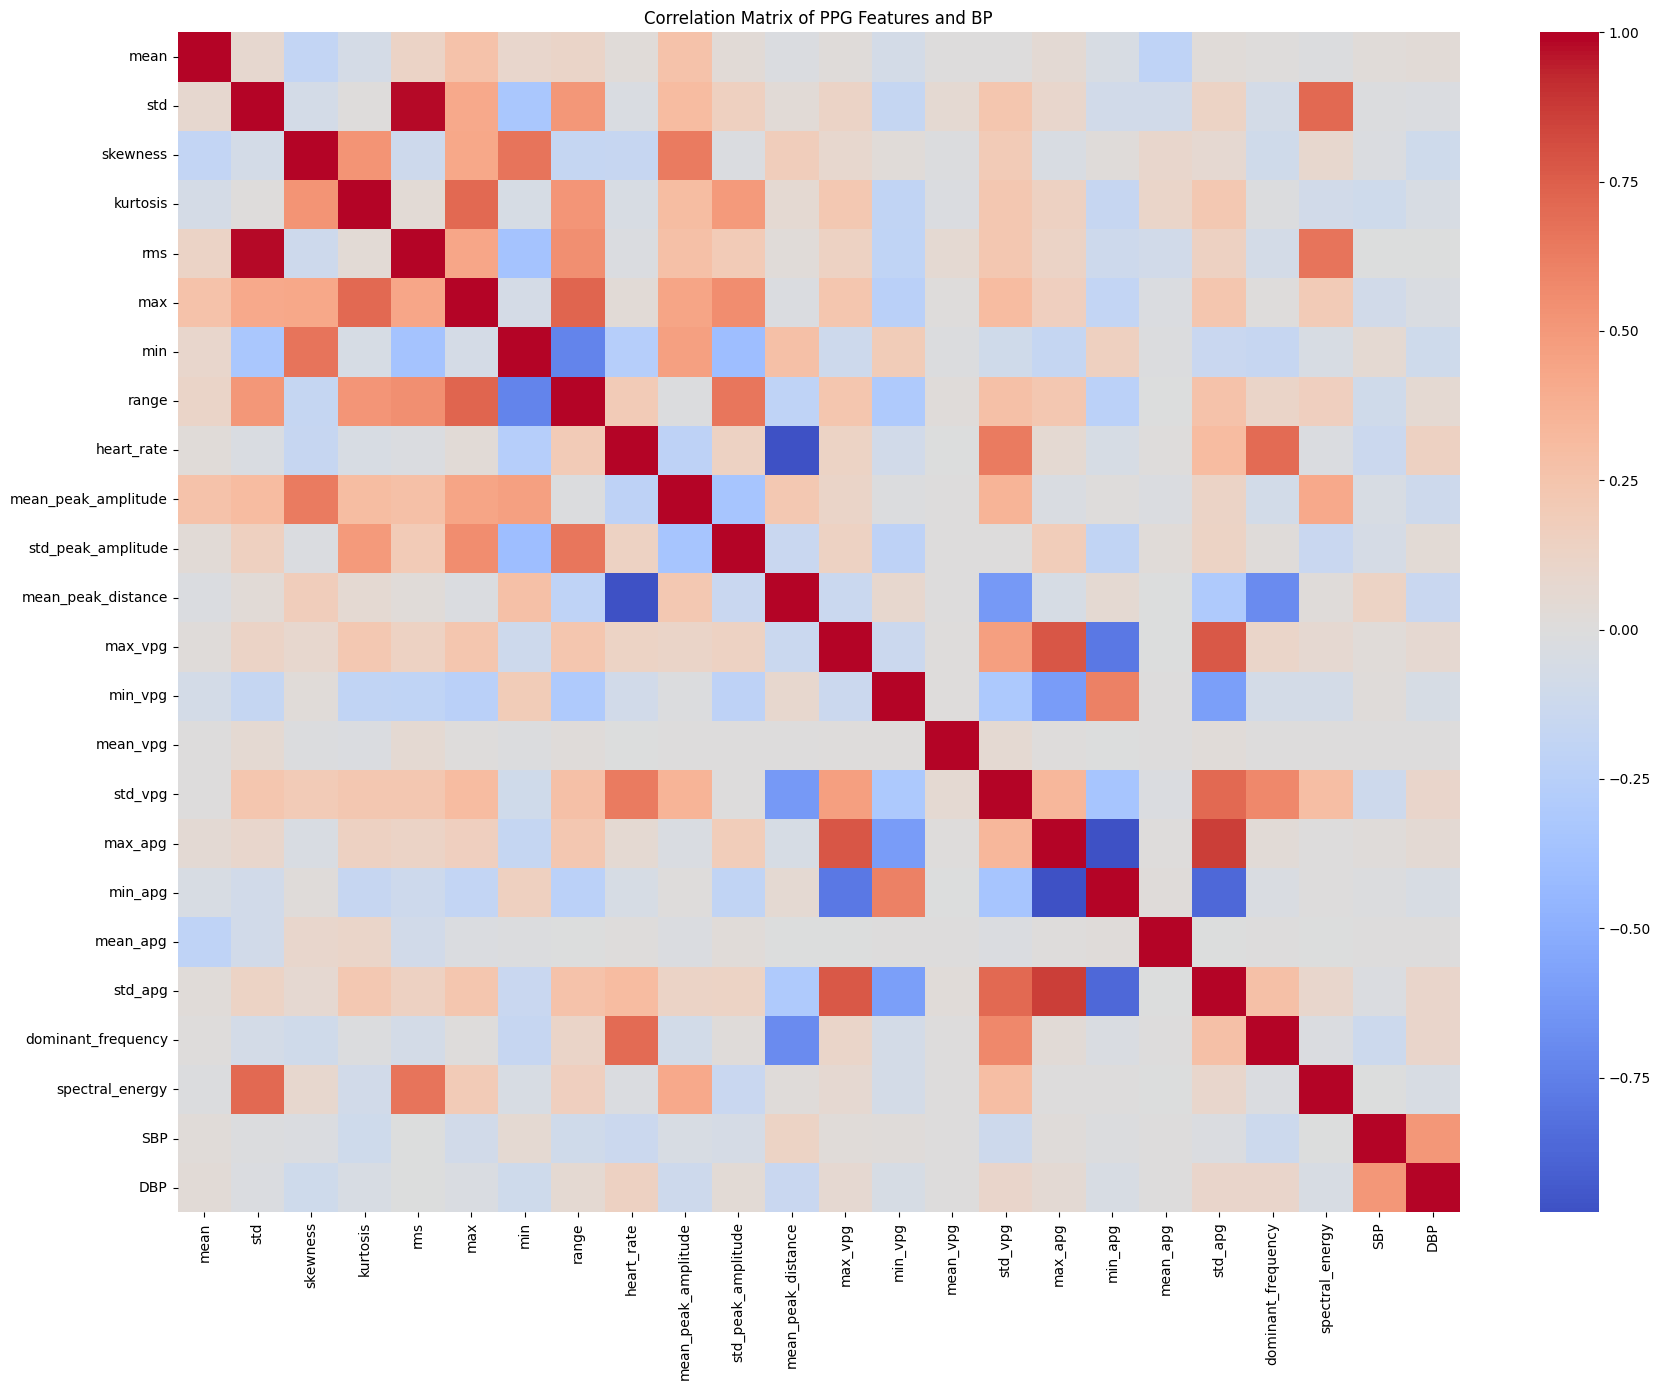

In [ ]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of PPG Features and BP")
plt.tight_layout()

plt.show()

In [ ]:
bp_corr = corr[["SBP", "DBP"]].sort_values(
    "SBP",
    ascending=False
)

print(bp_corr)

                          SBP       DBP
SBP                  1.000000  0.512698
DBP                  0.512698  1.000000
mean_peak_distance   0.131803 -0.148791
min                  0.055697 -0.109873
mean                 0.027342  0.029604
max_vpg              0.024030  0.062001
min_vpg              0.019125 -0.051151
max_apg              0.017454  0.049336
mean_apg             0.000155 -0.000698
mean_vpg             0.000127 -0.000094
rms                 -0.005454 -0.010747
spectral_energy     -0.010830 -0.046180
std                 -0.011393 -0.025320
min_apg             -0.011762 -0.046059
skewness            -0.020120 -0.103866
std_apg             -0.021268  0.098366
mean_peak_amplitude -0.046596 -0.115585
std_peak_amplitude  -0.062880  0.042961
max                 -0.094673 -0.027020
range               -0.102702  0.057107
kurtosis            -0.108086 -0.044481
std_vpg             -0.118244  0.102504
dominant_frequency  -0.122047  0.097684
heart_rate          -0.133108  0.146173


In [ ]:
feature_columns = [
    "mean",
    "std",
    "skewness",
    "kurtosis",
    "rms",
    "max",
    "min",
    "range",

    "heart_rate",
    "mean_peak_amplitude",
    "std_peak_amplitude",
    "mean_peak_distance",

    "max_vpg",
    "min_vpg",
    "mean_vpg",
    "std_vpg",

    "max_apg",
    "min_apg",
    "mean_apg",
    "std_apg",

    "dominant_frequency",
    "spectral_energy"
]

X_train = df_train[feature_columns]
X_val = df_val[feature_columns]
X_test = df_test[feature_columns]

y_train_sbp = df_train["SBP"]
y_val_sbp = df_val["SBP"]
y_test_sbp = df_test["SBP"]

y_train_dbp = df_train["DBP"]
y_val_dbp = df_val["DBP"]
y_test_dbp = df_test["DBP"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()

# Train
model.fit(X_train, y_train_sbp)
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train_sbp, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_sbp, train_pred))
print("Training MAE:", train_mae)
print("Training RMSE:", train_rmse)
# Validation
val_pred = model.predict(X_val)

val_mae = mean_absolute_error(y_val_sbp, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_sbp, val_pred))

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)

# Final test
sbp_pred = model.predict(X_test)

Training MAE: 17.31085288946991
Training RMSE: 21.46221815041702
Validation MAE: 17.401329911136546
Validation RMSE: 21.587689327204163


In [ ]:
sbp_mae = mean_absolute_error(
    y_test_sbp,
    sbp_pred
)

sbp_rmse = np.sqrt(
    mean_squared_error(
        y_test_sbp,
        sbp_pred
    )
)

sbp_r2 = r2_score(
    y_test_sbp,
    sbp_pred
)

print("SBP MAE :", sbp_mae)
print("SBP RMSE:", sbp_rmse)
print("SBP R²   :", sbp_r2)

SBP MAE : 17.57871803937934
SBP RMSE: 21.857223785956673
SBP R²   : 0.05145683724392802


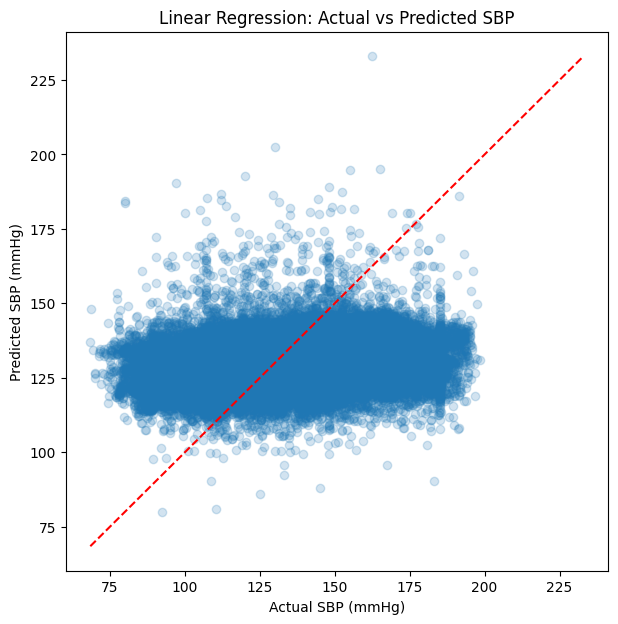

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_sbp,
    sbp_pred,
    alpha=0.2
)

min_val = min(
    y_test_sbp.min(),
    sbp_pred.min()
)

max_val = max(
    y_test_sbp.max(),
    sbp_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual SBP (mmHg)")
plt.ylabel("Predicted SBP (mmHg)")
plt.title("Linear Regression: Actual vs Predicted SBP")

plt.show()